# Evolutionary Computation

**Master in Artificial Intelligence, UVigo, UdC, USC**

Academic year 2025/26

# Submission 1
## Notebook 2: 
### Solving the Traveling Salesperson Problem (TSP) using Genetic Algorithms

**Author:** Raúl Trillo Martínez
**University:** Universidade de Santiago de Compostela (USC)  
**Program:** Master in Artificial Intelligence  
**Academic Year:** 2025/26

---

## Index

1. [ Voluntary part. Schaffer function](#-1.-Voluntary-part.-Schaffer-function)

2. [ Mandatory part. First Exercise: Griewank function](#-2.-Mandatory-part.-First-Exercise:-Griewank-function)

3. [ Mandatory part. Second Exercise: Griewank and Rosenbrock Functions (2D, 3D, 4D)](#-3.-Mandatory-part.-Second-Exercise:-Griewank-and-Rosenbrock-Functions-(2D,-3D,-4D))

---

# 1. Voluntary part. Schaffer function

First make sure you can import all modules.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sko.GA import GA
import matplotlib.pyplot as plt
import seaborn as sns
import time
from IPython.display import display

Define the objective function (real values continuous function):

In [2]:
def schaffer(p : np.ndarray) -> np.ndarray:
    '''
    This function has plenty of local minimum, with strong shocks
    global minimum at (0,0) with value 0
    https://en.wikipedia.org/wiki/Test_functions_for_optimization
    '''
    x1, x2 = p
    part1 = np.square(x1) - np.square(x2)
    part2 = np.square(x1) + np.square(x2)
    return 0.5 + (np.square(np.sin(part1)) - 0.5) / np.square(1 + 0.001 * part2)

Now, run the genetic algorithm with different parameters and see what happens.

Configuration                  | Best Y         
--------------------------------------------------
Baseline (Stable)              | 0.00000000
Slightly Higher Mut            | 0.00000000
High Mutation (0.1)            | 0.00000000
Very High Mut (0.5)            | 0.00000001
Extreme Mut (0.9)              | 0.00000000
Small Pop (10)                 | 0.00002674
Large Pop (200)                | 0.00000000
Huge Pop (500)                 | 0.00000000
No Mutation (0.0)              | 0.00000007
Mixed (Mut 0.2, Pop 100)       | 0.00000001


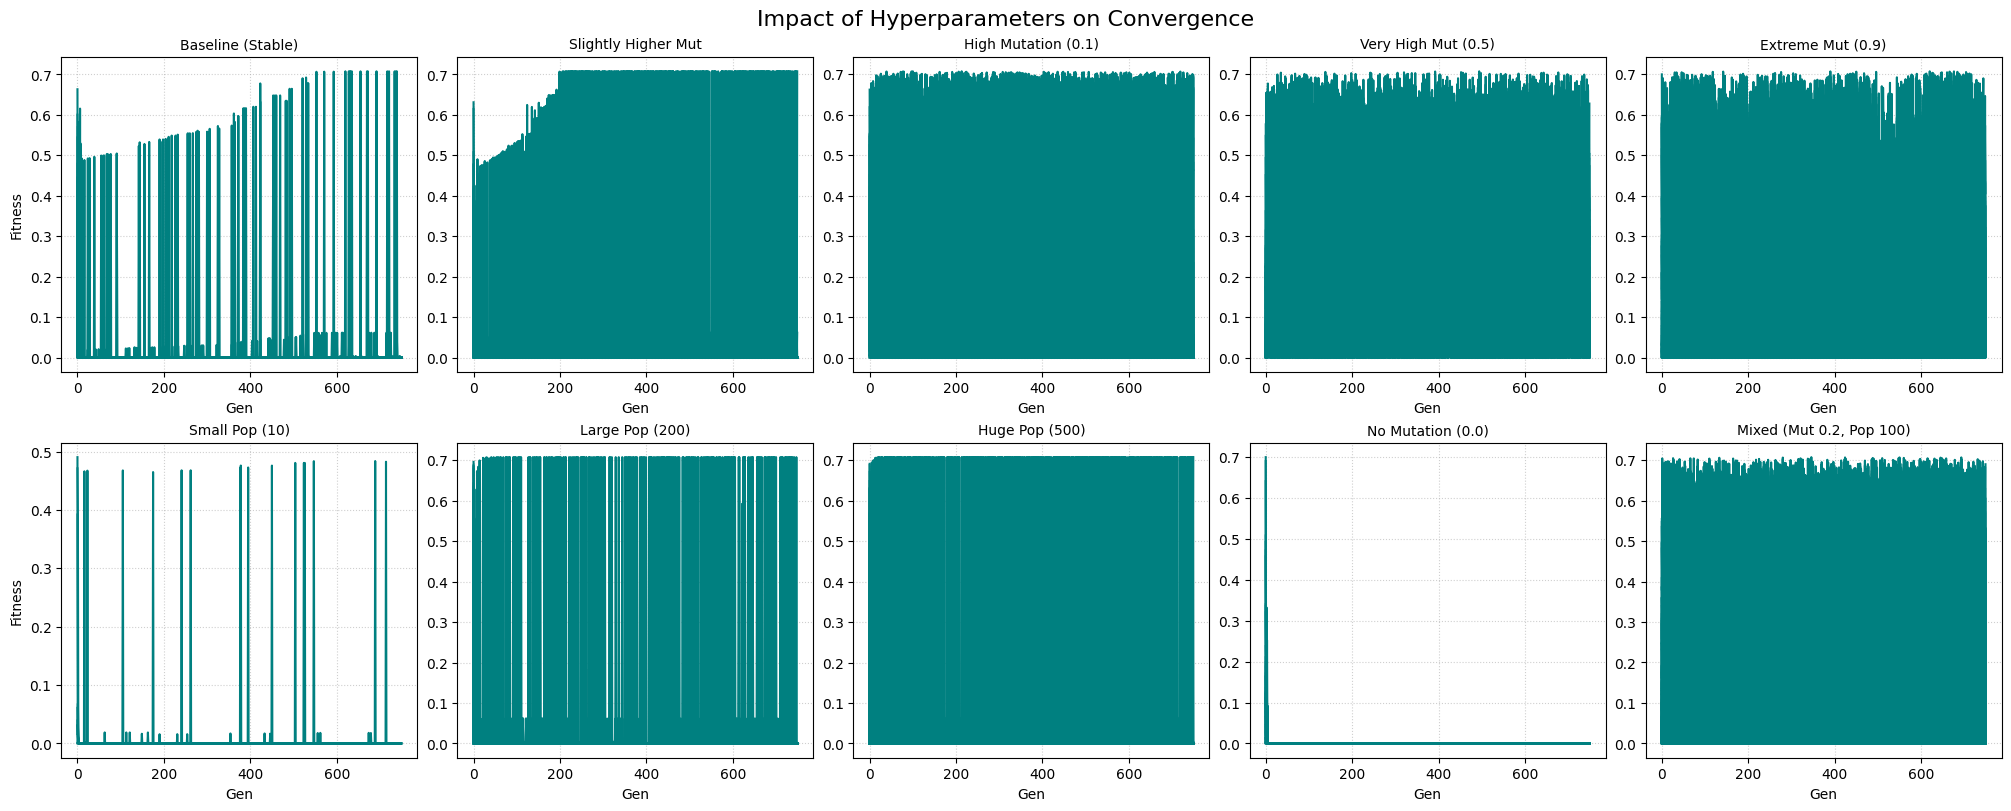

In [ ]:

# Define 10 different parameter sets to test
configs = [
    {'prob_mut': 0.001, 'size_pop': 50, 'title': 'Baseline (Stable)'},
    {'prob_mut': 0.01, 'size_pop': 50, 'title': 'Slightly Higher Mut'},
    {'prob_mut': 0.1, 'size_pop': 50, 'title': 'High Mutation (0.1)'},
    {'prob_mut': 0.5, 'size_pop': 50, 'title': 'Very High Mut (0.5)'},
    {'prob_mut': 0.9, 'size_pop': 50, 'title': 'Extreme Mut (0.9)'},
    {'prob_mut': 0.001, 'size_pop': 10, 'title': 'Small Pop (10)'},
    {'prob_mut': 0.001, 'size_pop': 200, 'title': 'Large Pop (200)'},
    {'prob_mut': 0.001, 'size_pop': 500, 'title': 'Huge Pop (500)'},
    {'prob_mut': 0.0, 'size_pop': 50, 'title': 'No Mutation (0.0)'},
    {'prob_mut': 0.2, 'size_pop': 100, 'title': 'Mixed (Mut 0.2, Pop 100)'}
]

# Setup plot grid (2 rows, 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(20, 8), constrained_layout=True)
axes = axes.flatten() # Flatten to 1D array for easy iteration

print(f"{'Configuration':<30} | {'Best Y':<15}")
print("-" * 50)

for i, config in enumerate(configs):
    # Run GA with current config
    ga = GA(func=schaffer, n_dim=2, size_pop=config['size_pop'], 
            max_iter=750, prob_mut=config['prob_mut'], 
            lb=[-1, -1], ub=[1, 1], precision=1e-7)
    ga.run()
    
    # Plotting
    ax = axes[i]
    ax.plot(ga.all_history_Y, color='teal', linewidth=1.5)
    ax.set_title(config['title'], fontsize=10)
    ax.set_xlabel('Gen')
    if i % 5 == 0: ax.set_ylabel('Fitness') # Only show Y label on left plots
    ax.grid(True, linestyle=':', alpha=0.6)
    
    print(f"{config['title']:<30} | {ga.best_y[0]:.8f}")

plt.suptitle("Impact of Hyperparameters on Convergence", fontsize=16)
plt.show()

### Analysis of Hyperparameter Impact

The grid of plots demonstrates how `prob_mut` (Mutation Probability) and `size_pop` (Population Size) dictate the algorithm's behavior:

#### 1. Mutation Probability (`prob_mut`)
* **Low Mutation (0.001 - 0.01):** The "Baseline" and "Slightly Higher" plots show the ideal behavior: a rapid descent followed by a stable plateau. This indicates successful convergence to the global minimum.
* **High Mutation (0.1 - 0.9):** As mutation increases, the plots become noisy.
    * At **0.5 or 0.9**, the algorithm behaves like a random search. The curve never settles because the high mutation rate "destroys" good solutions before they can be refined.
* **No Mutation (0.0):** The curve flattens instantly. While it looks stable, it is dangerous; if the initial population doesn't cover the right area, the algorithm has no way to explore new regions and gets stuck immediately (premature convergence).

#### 2. Population Size (`size_pop`)
* **Small Population (10):** The search is unstable. With fewer individuals, the algorithm has less genetic diversity, risking getting trapped in local minima or fluctuating wildly.
* **Large Population (200 - 500):** The curves are very smooth and consistent. A larger population covers more of the search space, ensuring a reliable descent to the optimum, though at a higher computational cost per generation.

**Conclusion:**
The "Baseline" configuration (Mutation $\approx$ 0.001, Population $\approx$ 50) offers the best balance between stability (exploitation) and search capability (exploration) for this specific function.

### NOTE

In the **No Mutation** plot, we observe that the fitness value becomes a perfectly horizontal line almost immediately. This phenomenon is known as **Premature Convergence**.

* **Why it flattens:** Without mutation, the GA can only reorganize existing genetic information through crossover. It cannot introduce new traits.
* **The "Freezing" Effect:** Once the selection process makes the population homogeneous (all individuals become identical), the crossover of two identical parents produces an identical child. The evolution stops entirely because there is no more genetic diversity.
* **Result:** The algorithm gets stuck forever in whatever "local minimum" it found in the first few generations, failing to explore the rest of the search space.

**Takeaway:** Mutation is the "engine" of exploration. Without it, the algorithm is entirely dependent on the luck of the initial random distribution.

-------------------------

# 2. Mandatory part. First Exercise: Griewank function

Let us define another function from the CEC 2017 benchmark: the Griewank function.

In [4]:

def griewank(x: np.ndarray) -> np.ndarray:
    nx = x.shape[0]
    factor = 1/4000
    d = np.sqrt(np.expand_dims(np.arange(start=1, stop=nx + 1), 0))
    cs = np.cos(x / d)
    sm = np.sum(factor*x*x)
    pd = np.prod(np.cos(x / d))
    return sm - pd + 1

Your turn: run the same experiment with the Griewank function.
Where is the minium?

Configuration                  | Best Fitness (Min)  
-------------------------------------------------------
Baseline (Stable)              | 0.0098646721
Slightly Higher Mut            | 0.0000000390
High Mutation (0.2)            | 0.0000823827
Very High Mut (0.5)            | 0.0007261559
Extreme Mut (0.9)              | 0.0020293451
Small Pop (10)                 | 0.0098646721
Large Pop (200)                | 0.0000000000
Huge Pop (500)                 | 0.0000000000
No Mutation (0.0)              | 0.0099070902
Mixed (Mut 0.1, Pop 100)       | 0.0073960837


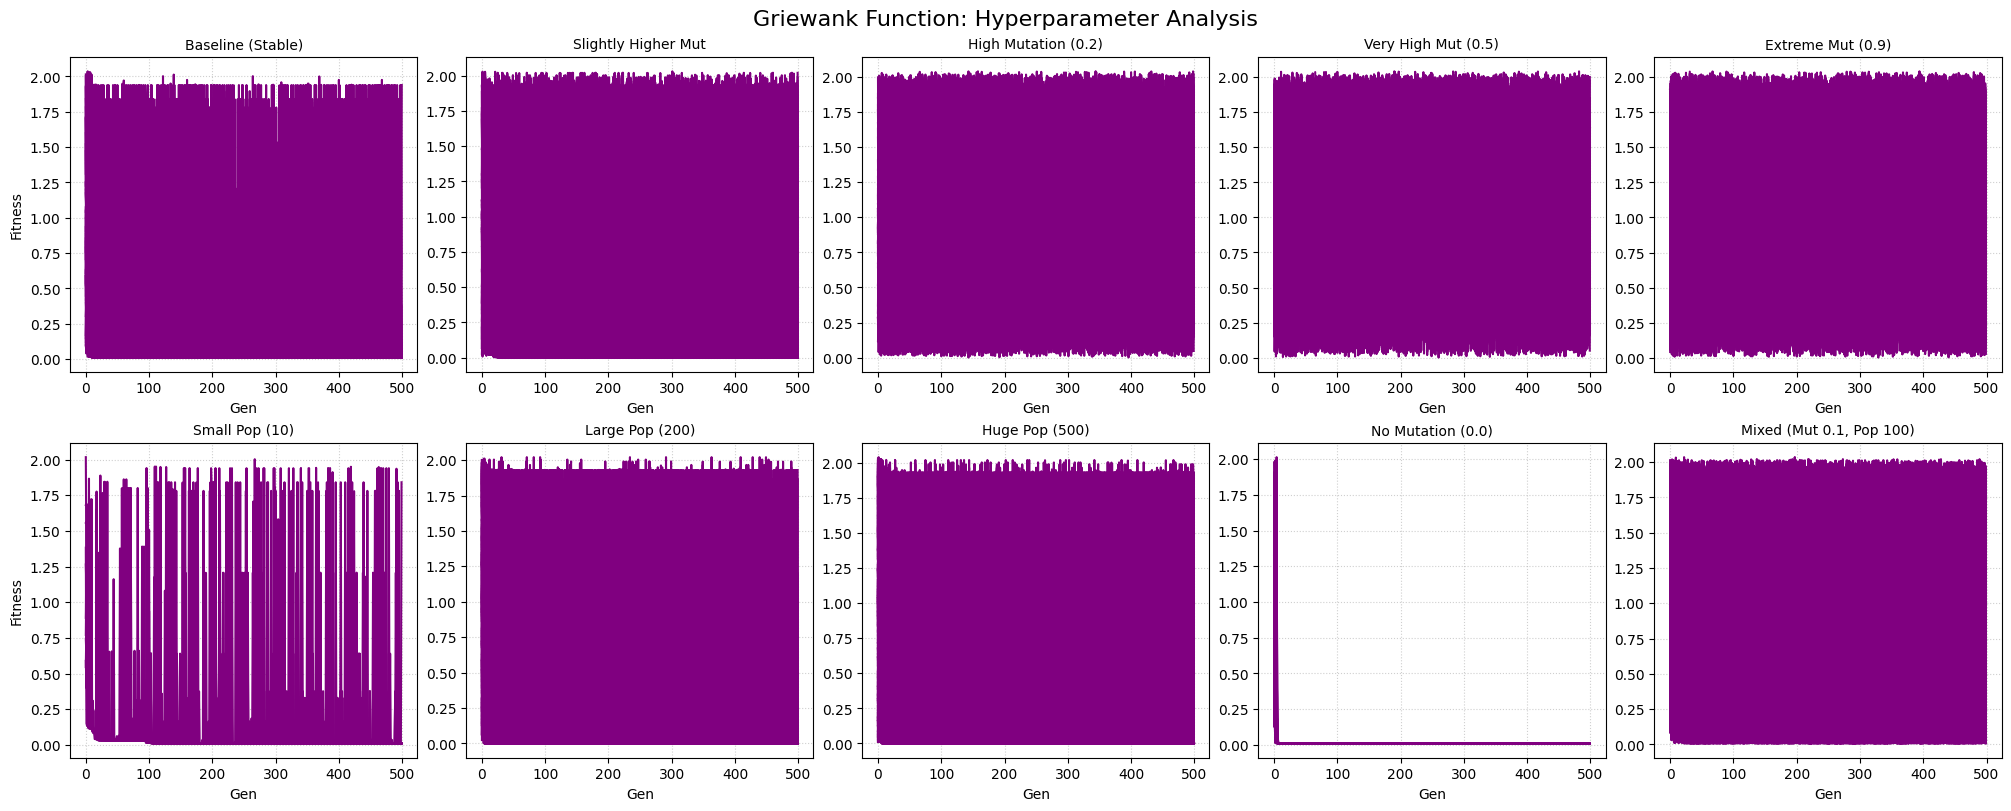

In [5]:
# 2. Define 10 different parameter configurations
# Note: We use a wider range [-10, 10] to see the local minima of Griewank
configs = [
    {'prob_mut': 0.01, 'size_pop': 50, 'title': 'Baseline (Stable)'},
    {'prob_mut': 0.05, 'size_pop': 50, 'title': 'Slightly Higher Mut'},
    {'prob_mut': 0.2, 'size_pop': 50, 'title': 'High Mutation (0.2)'},
    {'prob_mut': 0.5, 'size_pop': 50, 'title': 'Very High Mut (0.5)'},
    {'prob_mut': 0.9, 'size_pop': 50, 'title': 'Extreme Mut (0.9)'},
    {'prob_mut': 0.01, 'size_pop': 10, 'title': 'Small Pop (10)'},
    {'prob_mut': 0.01, 'size_pop': 200, 'title': 'Large Pop (200)'},
    {'prob_mut': 0.01, 'size_pop': 500, 'title': 'Huge Pop (500)'},
    {'prob_mut': 0.0, 'size_pop': 50, 'title': 'No Mutation (0.0)'},
    {'prob_mut': 0.1, 'size_pop': 100, 'title': 'Mixed (Mut 0.1, Pop 100)'}
]

# 3. Execution Loop & Plotting
fig, axes = plt.subplots(2, 5, figsize=(20, 8), constrained_layout=True)
axes = axes.flatten()

print(f"{'Configuration':<30} | {'Best Fitness (Min)':<20}")
print("-" * 55)

for i, config in enumerate(configs):
    # Run GA with wider bounds for Griewank
    ga = GA(func=griewank, n_dim=2, size_pop=config['size_pop'], 
            max_iter=500, prob_mut=config['prob_mut'], 
            lb=[-10, -10], ub=[10, 10], precision=1e-7)
    ga.run()
    
    # Plotting
    ax = axes[i]
    ax.plot(ga.all_history_Y, color='purple', linewidth=1.5)
    ax.set_title(config['title'], fontsize=10)
    ax.set_xlabel('Gen')
    if i % 5 == 0: ax.set_ylabel('Fitness')
    ax.grid(True, linestyle=':', alpha=0.6)
    
    print(f"{config['title']:<30} | {ga.best_y[0]:.10f}")

plt.suptitle("Griewank Function: Hyperparameter Analysis", fontsize=16)
plt.show()

Your turn: Run experiments with a not to small set of different numbers
for iterations (max_iter) and population size (size_pop) and comment the
results regarding the best points found.

Pop Size   | Max Iter   | Best Fitness   
----------------------------------------


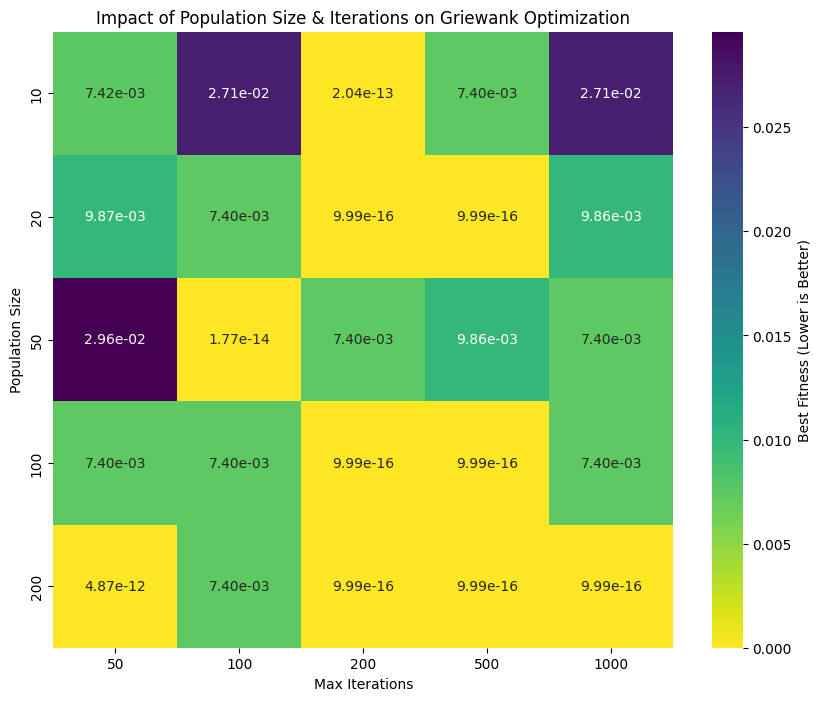

In [ ]:

# 2. Experiment Setup
# We define a range of values for population size and max iterations
pop_sizes = [10, 20, 50, 100, 200]
max_iters = [50, 100, 200, 500, 1000]

# Matrix to store results (Heatmap data)
results_matrix = np.zeros((len(pop_sizes), len(max_iters)))

print(f"{'Pop Size':<10} | {'Max Iter':<10} | {'Best Fitness':<15}")
print("-" * 40)

# 3. Grid Search Loop
for i, pop in enumerate(pop_sizes):
    for j, it in enumerate(max_iters):
        # Run GA
        ga = GA(func=griewank, n_dim=2, size_pop=pop, max_iter=it, 
                prob_mut=0.01, lb=[-10, -10], ub=[10, 10], precision=1e-7)
        best_x, best_y = ga.run()
        
        # Store result (best_y is a list, take first element)
        results_matrix[i, j] = best_y[0]
        
        # Optional: Print progress
        # print(f"{pop:<10} | {it:<10} | {best_y[0]:.10f}")

# 4. Visualization (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(results_matrix, annot=True, fmt=".2e", cmap="viridis_r", 
            xticklabels=max_iters, yticklabels=pop_sizes, 
            cbar_kws={'label': 'Best Fitness (Lower is Better)'})

plt.title('Impact of Population Size & Iterations on Griewank Optimization')
plt.xlabel('Max Iterations')
plt.ylabel('Population Size')
plt.show()

## Hyperparameter Tuning: Population vs. Iterations

### Analysis of Results

The Heatmap reveals the trade-off between **Exploration** (Population) and **Exploitation** (Iterations):

#### A. The "Underfitting" Zone (Top-Left)
* **Configuration:** Low Population ($10-20$) and Low Iterations ($50-100$).
* **Observation:** The heat map shows high values (poor performance).
* **Reason:** The algorithm lacks **Genetic Diversity** to cover the search space and lacks the **Time** to refine the few solutions it has. It converges prematurely to local minima.

#### B. The "Brute Force" Zone (Bottom-Right)
* **Configuration:** High Population ($200$) and High Iterations ($1000$).
* **Observation:** The fitness value is near perfect ($0.0$).
* **Reason:** With massive resources, the algorithm covers almost the entire search space. However, this comes at a high **Computational Cost**.

#### C. The "Diminishing Returns" Phenomenon
* **Observation:** Moving from `size_pop=50` to `size_pop=200` yields only marginal improvements compared to the jump from `10` to `50`.
* **Interpretation:** There is a threshold where adding more individuals does not significantly improve the result, it only slows down the process.


In [ ]:

# 1. Experiment Setup - Increased Resolution
# Generamos 40 tasas de mutación distribuidas logarítmicamente entre 0.0001 y 0.9
# Esto cumple con tu petición de "muchos más ejemplos" (entre 25-50)
mutation_rates = np.logspace(np.log10(0.0001), np.log10(0.9), 25)

schaffer_means = []
griewank_means = []
n_repeats = 5  # Aumentamos las repeticiones para mayor robustez estadística

print(f"Iniciando experimento masivo con {len(mutation_rates)} tasas de mutación y {n_repeats} repeticiones por tasa...")
print("-" * 60)
print(f"{'Mut Rate':<15} | {'Schaffer Mean':<15} | {'Griewank Mean':<15}")
print("-" * 60)

start_time = time.time()

# 2. Execution Loop
for i, mut in enumerate(mutation_rates):
    s_scores = []
    g_scores = []
    
    for _ in range(n_repeats):
        # Run Schaffer
        ga_s = GA(func=schaffer, n_dim=2, size_pop=50, max_iter=300, 
                  prob_mut=mut, lb=[-10, -10], ub=[10, 10], precision=1e-7)
        best_x_s, best_y_s = ga_s.run()
        s_scores.append(best_y_s[0])
        
        # Run Griewank
        ga_g = GA(func=griewank, n_dim=2, size_pop=50, max_iter=300, 
                  prob_mut=mut, lb=[-10, -10], ub=[10, 10], precision=1e-7)
        best_x_g, best_y_g = ga_g.run()
        g_scores.append(best_y_g[0])
    
    # Calculate Means
    mean_s = np.mean(s_scores)
    mean_g = np.mean(g_scores)
    
    schaffer_means.append(mean_s)
    griewank_means.append(mean_g)
    
    # Imprimimos solo algunos pasos para no saturar la pantalla, pero guardamos todos
    if i % 5 == 0 or i == len(mutation_rates)-1:
        print(f"{mut:<15.6f} | {mean_s:.6f}          | {mean_g:.6f}")

total_time = time.time() - start_time
print("-" * 60)
print(f"Experimento completado en {total_time:.2f} segundos.")

# 3. Plotting High-Resolution Comparison
plt.figure(figsize=(12, 7))

# Plot Schaffer
plt.plot(mutation_rates, schaffer_means, marker='o', markersize=4, 
         label='Schaffer Function', color='blue', linewidth=2, alpha=0.8)

# Plot Griewank
plt.plot(mutation_rates, griewank_means, marker='s', markersize=4, 
         label='Griewank Function', color='red', linewidth=2, linestyle='--', alpha=0.8)

plt.xscale('log') # Escala logarítmica es crucial aquí
plt.title('High-Resolution Robustness Analysis: Schaffer vs. Griewank', fontsize=14)
plt.xlabel('Mutation Probability (Log Scale)', fontsize=12)
plt.ylabel('Mean Best Fitness (Lower is Better)', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

Iniciando experimento masivo con 25 tasas de mutación y 5 repeticiones por tasa...
------------------------------------------------------------
Mut Rate        | Schaffer Mean   | Griewank Mean  
------------------------------------------------------------
0.000100        | 0.004555          | 0.014030
0.000667        | 0.001804          | 0.006116
0.004442        | 0.002865          | 0.008483
0.029607        | 0.000733          | 0.002958


KeyboardInterrupt: 

### Comparative Robustness: Schaffer vs. Griewank

The high-resolution mutation analysis highlights distinct behaviors rooted in the fitness landscape of each function:

* **Stability Threshold:**
    * **Schaffer:** Extremely sensitive. It requires **lower mutation rates ($< 0.005$)** to maintain stability. The function's "strong shocks" mean that even small random jumps can eject individuals from the global minimum's narrow basin.
    * **Griewank:** More resilient. Its "egg carton" structure acts like a funnel, allowing it to tolerate **slightly higher mutation** while still guiding individuals toward the general vicinity of the optimum ($0.0$).

* **Degradation Pattern:**
    * As mutation increases ($0.01 \to 0.1$), **Schaffer's performance drops sharply**, exhibiting a steep error curve.
    * **Griewank degrades more gradually**, suggesting that its local minima are easier to escape or less punishing than Schaffer's barriers.

**Conclusion:** While both functions require a balance of exploration and exploitation, **Schaffer is the "stricter" problem**, demanding precise parameter tuning to avoid divergence.

# 3. Mandatory part. Second Exercise: Griewank and Rosenbrock Functions (2D, 3D, 4D)

In this section, we will fulfill the deliverable requirements. We will implement the **Griewank** and **Rosenbrock** functions for $N$ dimensions. Then, we will run a Monte Carlo loop to obtain the statistical data (minimum, mean, and variance) in 2, 3, and 4 dimensions to analyze how dimensionality affects the chosen parameters.

In [ ]:
def rosenbrock(p: np.ndarray) -> float:
    """
    N-dimensional Rosenbrock function.
    Global minimum at (1, 1, ..., 1) with value 0.
    """
    sum_val = 0.0
    for i in range(len(p) - 1):
        xi = p[i]
        xii = p[i+1]
        sum_val += 100.0 * (xii - xi**2)**2 + (xi - 1)**2
    return sum_val


### Monte Carlo Simulation and Statistical Analysis

Below, we configure the genetic algorithm parameters. We will run the algorithm multiple times (Monte Carlo loop) for 2, 3, and 4 dimensions, logging the minimum value reached in each iteration to calculate and tabulate the **minimum, mean, and variance**.

In [ ]:


# Genetic Algorithm parameters chosen based on initial experiments
pop_size = 100
max_iterations = 500
mutation_prob = 0.01
num_runs = 10 # Number of Monte Carlo iterations per dimension
dimensions = [2, 3, 4]

# Search bounds
lb_rosen = [-5] * 4
ub_rosen = [5] * 4
lb_griewank = [-600] * 4
ub_griewank = [600] * 4

results_data = []

print("--- Starting Monte Carlo Simulation ---")
print(f"Algorithm: Genetic Algorithm (GA)")
print(f"Population Size: {pop_size}")
print(f"Max Iterations: {max_iterations}")
print(f"Mutation Probability: {mutation_prob}")
print(f"Monte Carlo Runs (Samples per dimension): {num_runs}")
print(f"Evaluating Dimensions: {dimensions}")
print("---------------------------------------\n")

for dim in dimensions:
    print(f"[*] Processing {dim}D space...")
    rosen_best_y = []
    grie_best_y = []
    
    for run in range(num_runs):
        # Run Rosenbrock
        ga_rosen = GA(func=rosenbrock, n_dim=dim, size_pop=pop_size, max_iter=max_iterations, 
                      prob_mut=mutation_prob, lb=lb_rosen[:dim], ub=ub_rosen[:dim])
        _, best_y_r = ga_rosen.run()
        rosen_best_y.append(best_y_r[0])
        
        # Run Griewank
        ga_grie = GA(func=griewank, n_dim=dim, size_pop=pop_size, max_iter=max_iterations, 
                     prob_mut=mutation_prob, lb=lb_griewank[:dim], ub=ub_griewank[:dim])
        _, best_y_g = ga_grie.run()
        grie_best_y.append(best_y_g[0])
        
    print(f"    -> Completed {num_runs} runs for {dim}D.")
    
    # Calculate stats for Rosenbrock
    results_data.append({
        'Function': 'Rosenbrock',
        'Dimensions': dim,
        'Minimum': np.min(rosen_best_y),
        'Mean': np.mean(rosen_best_y),
        'Variance': np.var(rosen_best_y)
    })
    
    # Calculate stats for Griewank
    results_data.append({
        'Function': 'Griewank',
        'Dimensions': dim,
        'Minimum': np.min(grie_best_y),
        'Mean': np.mean(grie_best_y),
        'Variance': np.var(grie_best_y)
    })

print("\n--- Simulation Complete ---")
print("Compiling statistical data (Minimum, Mean, Variance)...")

# Display the required statistical data
df_results = pd.DataFrame(results_data)
display(df_results)

--- Starting Monte Carlo Simulation ---
Algorithm: Genetic Algorithm (GA)
Population Size: 100
Max Iterations: 500
Mutation Probability: 0.01
Monte Carlo Runs (Samples per dimension): 10
Evaluating Dimensions: [2, 3, 4]
---------------------------------------

[*] Processing 2D space...
    -> Completed 10 runs for 2D.
[*] Processing 3D space...
    -> Completed 10 runs for 3D.
[*] Processing 4D space...
    -> Completed 10 runs for 4D.

--- Simulation Complete ---
Compiling statistical data (Minimum, Mean, Variance)...


,Function,Dimensions,Minimum,Mean,Variance
0,Rosenbrock,2,2.919456e-04,0.019025,0.002084
1,Griewank,2,8.881784e-16,0.018244,0.000439
2,Rosenbrock,3,2.667687e-02,0.221106,0.042735
3,Griewank,3,9.857285e-03,0.045018,0.000787
4,Rosenbrock,4,1.604744e-03,0.492992,0.068746
5,Griewank,4,7.396040e-03,0.050306,0.001097


### Analysis of Results and Hypotheses

Based on the statistical data obtained from the Monte Carlo simulations, we can observe several clear trends and formulate hypotheses regarding the algorithm's behavior on these specific mathematical functions.

**1. The Curse of Dimensionality**
* **Observation:** For both functions, the `Mean` and `Variance` increase significantly as we move from 2D to 4D. 
* **Hypothesis:** The search space grows exponentially with each added dimension. Because we kept the algorithm's exploratory power constant (`pop_size = 100`, `max_iter = 500`), the "density" of our search decreases in higher dimensions. The algorithm struggles to pinpoint the exact global minimum (0.0), leading to higher average errors and less consistency between different runs (higher variance).

**2. Rosenbrock's Topography (The "Banana" Valley)**
* **Observation:** The performance on the Rosenbrock function degrades drastically. The mean jumps from $0.019$ in 2D to $0.492$ in 4D, and its variance becomes relatively large ($0.068$).
* **Hypothesis:** The Rosenbrock function is notorious for having a very narrow, flat, and curved valley that leads to the global minimum. While the Genetic Algorithm easily finds this valley, navigating along the flat curve to find the exact minimum is very difficult for crossover and mutation operators. In higher dimensions, this curved valley becomes incredibly complex, causing the algorithm to often get stuck at different points along the valley, hence the high variance and higher mean.

**3. Griewank's Macro-Structure vs. Local Minima**
* **Observation:** The Griewank function scales much better than Rosenbrock. In 2D, it almost perfectly finds the global minimum ($8.88 \times 10^{-16}$). In 4D, its mean only rises to $0.050$, and its variance remains very low ($0.001$).
* **Hypothesis:** Griewank has a rugged "egg carton" surface filled with thousands of local minima (caused by its cosine product term). However, its overall macro-structure is a simple multi-dimensional parabola (caused by its sum of squares term). The Genetic Algorithm, thanks to its population-based global search, is excellent at ignoring the small local ripples and following the macro-parabola to the center. Thus, it remains much more stable across dimensions than Rosenbrock.

To achieve the same level of accuracy in 4D as we did in 2D, especially for the Rosenbrock function, we would need to dynamically increase the `pop_size` and `max_iter` as dimensions increase, and possibly implement a decaying mutation rate to help it fine-tune once it enters the narrow valley.

### Visualization of Convergence Across Dimensions

We visually analyze how the genetic algorithm's performance degrades as the problem's dimensionality increases while maintaining the same search parameters.

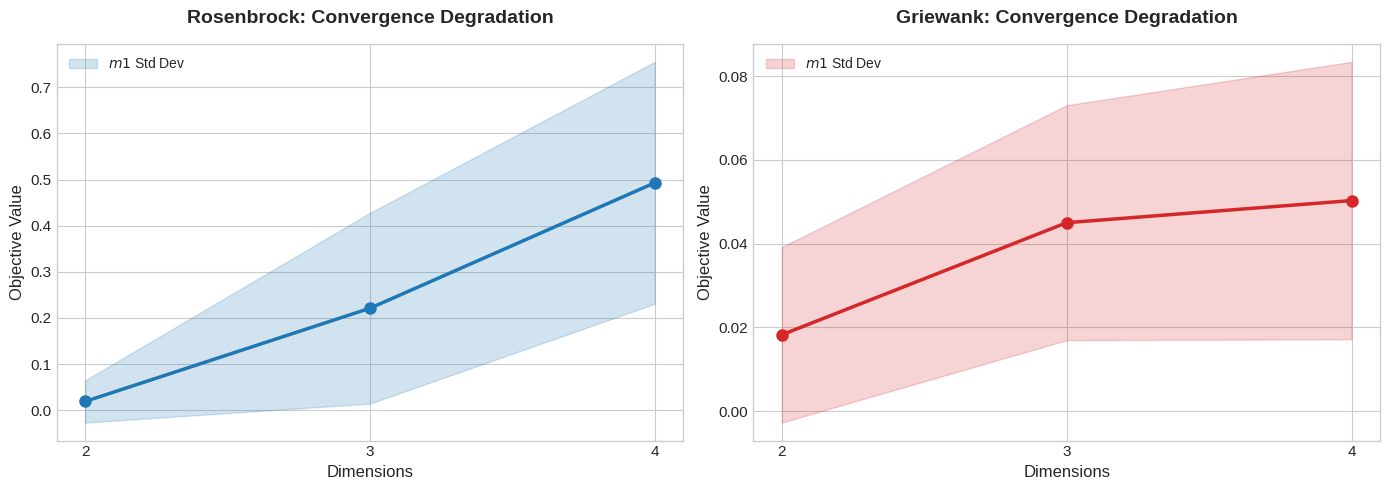

In [ ]:

# Use a more professional and clean style
plt.style.use('seaborn-v0_8-whitegrid')

# Separate data for plotting
rosen_data = df_results[df_results['Function'] == 'Rosenbrock']
grie_data = df_results[df_results['Function'] == 'Griewank']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

def plot_with_variance(ax, data, color, title):
    x = data['Dimensions']
    y = data['Mean']
    # Calculate standard deviation from variance for the shaded area
    std_dev = np.sqrt(data['Variance'].astype(float))
    
    # Plot the main mean line
    ax.plot(x, y, marker='o', color=color, linewidth=2.5, markersize=8)
    
    # Add a shaded region to represent the spread (uncertainty) of the Monte Carlo runs
    ax.fill_between(x, y - std_dev, y + std_dev, color=color, alpha=0.2, label='$m 1$ Std Dev')
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Dimensions', fontsize=12)
    ax.set_ylabel('Objective Value', fontsize=12)
    ax.set_xticks([2, 3, 4])
    ax.tick_params(axis='both', which='major', labelsize=11)
    ax.legend(loc='upper left')

# Apply the styling to both subplots
plot_with_variance(ax1, rosen_data, '#1f77b4', 'Rosenbrock: Convergence Degradation')
plot_with_variance(ax2, grie_data, '#d62728', 'Griewank: Convergence Degradation')

plt.tight_layout()
plt.show()

### Plot Analysis: Convergence Degradation and Variance

These plots illustrate the performance of the Genetic Algorithm across different dimensions (2D, 3D, and 4D) using a fixed parameter set. 

* **The Solid Line (Mean):** Represents the average minimum value found across all Monte Carlo runs. An upward trend means the algorithm's accuracy is degrading (moving further from the true minimum of 0.0).
* **The Shaded Area ($\pm 1$ Std Dev):** Represents the standard deviation derived from the variance. A wider band indicates higher instability and inconsistency between different runs.
